In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
os.listdir('/content/drive/MyDrive/my_projects')

['diabetes.csv', 'Pima_project.ipynb']

In [6]:
#load the dataset
df=pd.read_csv('/content/drive/MyDrive/my_projects/diabetes.csv')

In [7]:
# inspect dataset
df.head(30)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [8]:
df.shape

(768, 9)

In [9]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

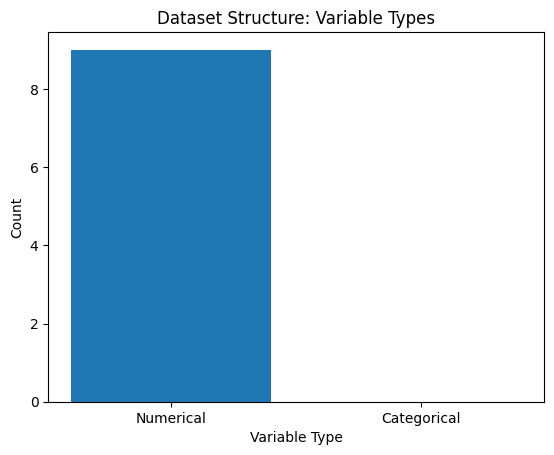

In [10]:
import matplotlib.pyplot as plt

# Data
types = ['Numerical', 'Categorical']
counts = [9, 0]

# Plot
plt.figure()
plt.bar(types, counts)

# Labels
plt.title("Dataset Structure: Variable Types")
plt.xlabel("Variable Type")
plt.ylabel("Count")

plt.show()

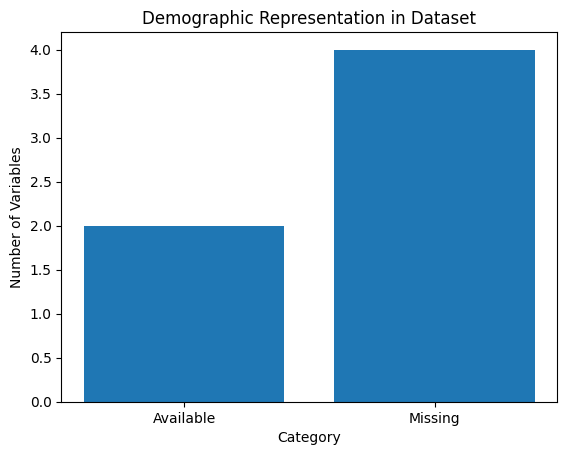

In [11]:
labels = ['Available', 'Missing']
counts = [2, 4]  # Age, Pregnancies vs missing ones

plt.figure()
plt.bar(labels, counts)

plt.title("Demographic Representation in Dataset")
plt.xlabel("Category")
plt.ylabel("Number of Variables")

plt.show()

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
# data cleaning- checking missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [15]:
# finding zero values
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [ ]:
# There are missing values in many cols - insulin, BMI, Glucose,age, BP,Skin thickness are
# impossible so the probability is missing data.These will distort the model accuracy, so replaced with median
# to reduce the impact of outliers and preserve the overall data distribution.

In [29]:
import numpy as np

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Replace zeros with NaN
df[cols] = df[cols].replace(0, np.nan)

# Fill with median (clean + no warning)
df[cols] = df[cols].fillna(df[cols].median())

In [30]:
# Rechecking zero values- only outcome - which is a binary variable and prgenancy -possible have zero values now.
(df == 0).sum()

,0
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


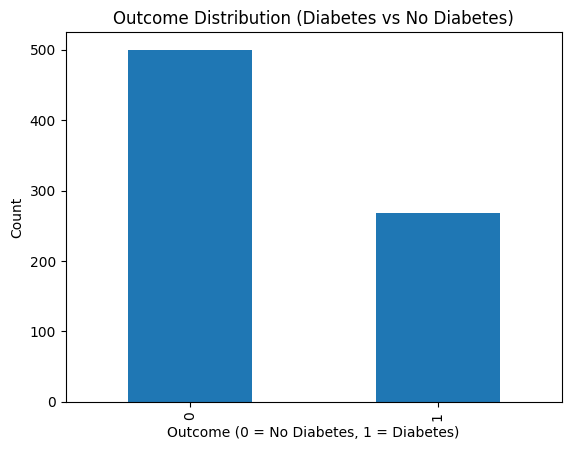

In [31]:
# eda - mean, correlation
outcome_counts = df['Outcome'].value_counts()

# Plot
plt.figure()
outcome_counts.plot(kind='bar')

# Labels
plt.title("Outcome Distribution (Diabetes vs No Diabetes)")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")

plt.show()

In [32]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [33]:
corr = df.corr(numeric_only=True)
print(corr['Outcome'].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


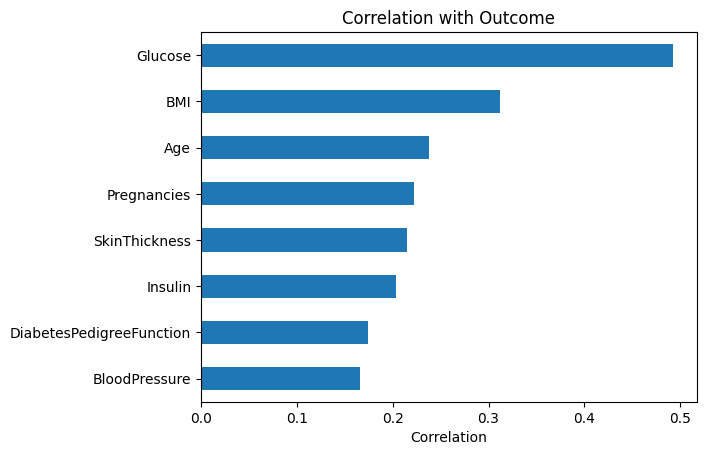

In [34]:
corr_target = corr['Outcome'].drop('Outcome')

plt.figure()
corr_target.sort_values().plot(kind='barh')
plt.title("Correlation with Outcome")
plt.xlabel("Correlation")
plt.show()

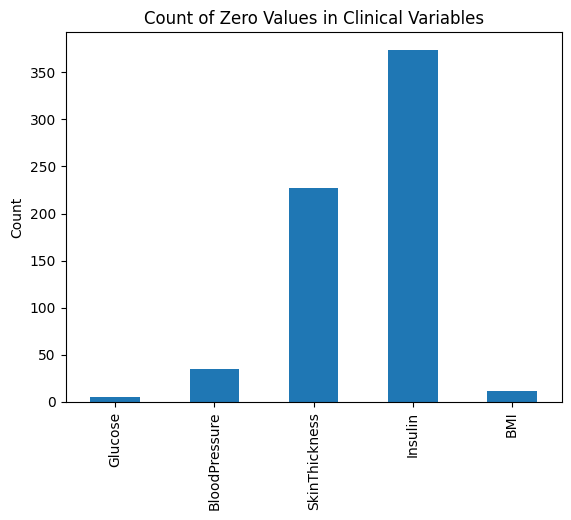

In [20]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

zero_counts = (df[cols] == 0).sum()

zero_counts.plot(kind='bar')
plt.title('Count of Zero Values in Clinical Variables')
plt.ylabel('Count')
plt.show()

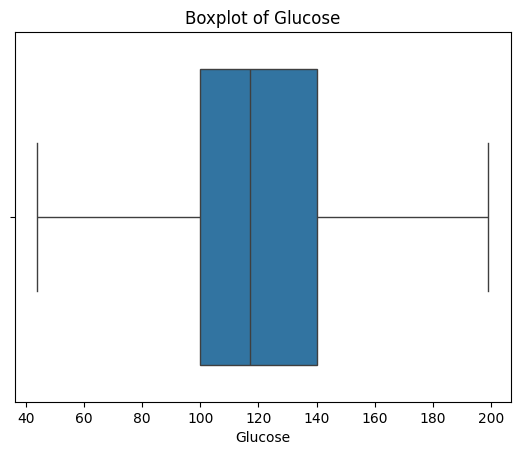

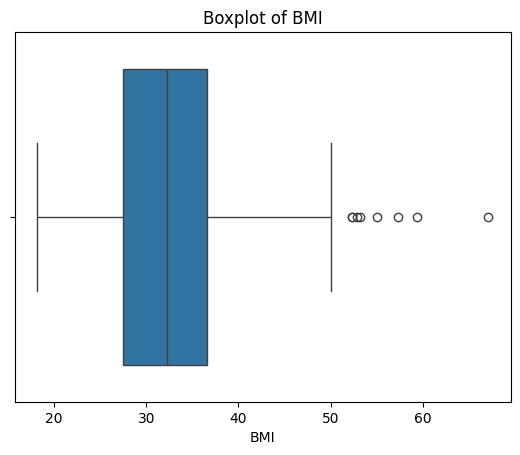

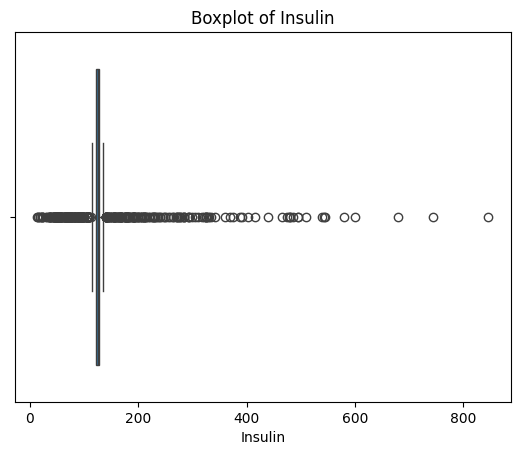

In [35]:
import seaborn as sns

cols = ['Glucose','BMI','Insulin']

for col in cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

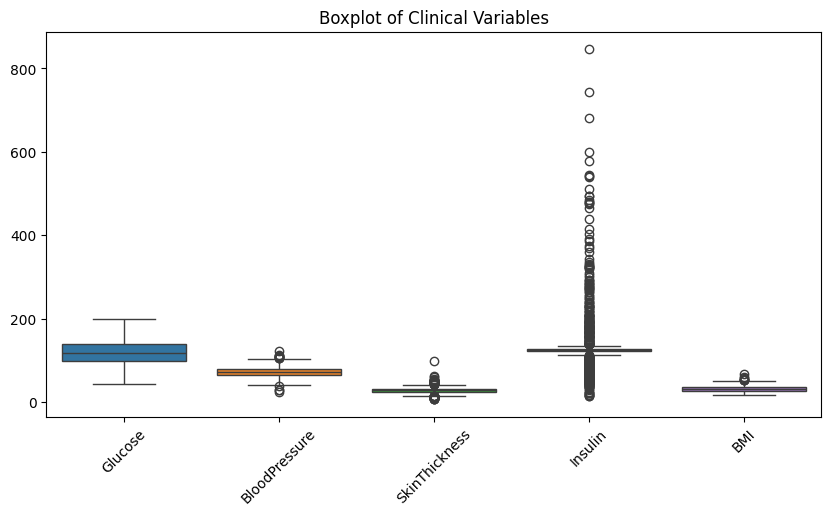

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

plt.figure(figsize=(10,5))
sns.boxplot(data=df[cols])
plt.title('Boxplot of Clinical Variables')
plt.xticks(rotation=45)
plt.show()

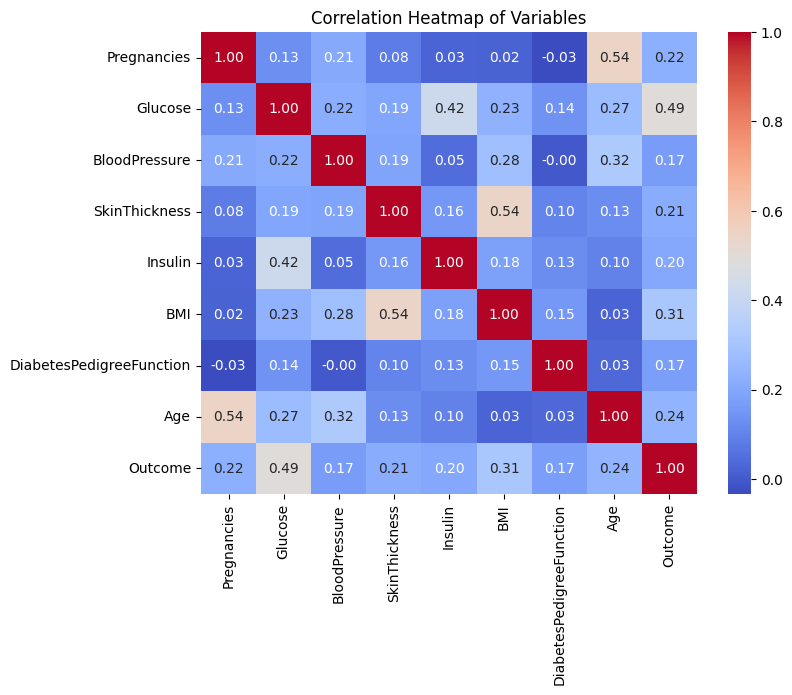

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap of Variables')
plt.show()

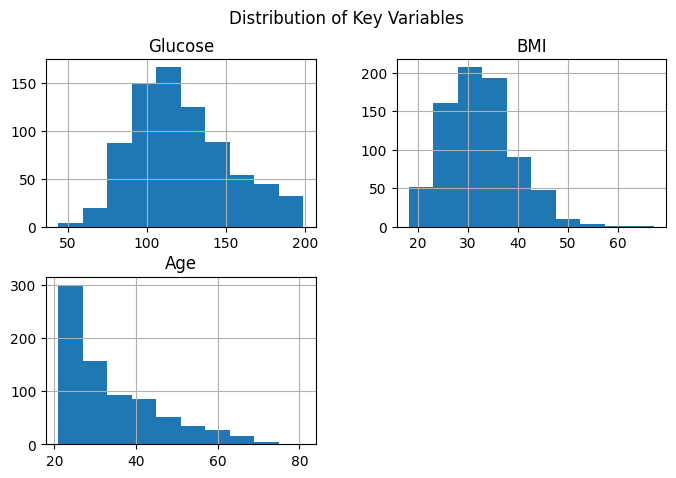

In [38]:
cols = ['Glucose','BMI','Age']

df[cols].hist(figsize=(8,5))
plt.suptitle('Distribution of Key Variables')
plt.show()

In [39]:
from scipy.stats import pearsonr
import pandas as pd

cols = df.columns
results = []

for col in cols:
    if col != 'Outcome':
        corr, p_val = pearsonr(df[col], df['Outcome'])
        results.append([col, corr, p_val])

corr_df = pd.DataFrame(results, columns=['Variable', 'Correlation', 'P-value'])
corr_df = corr_df.sort_values(by='Correlation', ascending=False)

corr_df

,Variable,Correlation,P-value
1,Glucose,0.492782,3.128719e-48
5,BMI,0.312038,8.336903e-19
7,Age,0.238356,2.209975e-11
0,Pregnancies,0.221898,5.065127e-10
3,SkinThickness,0.214873,1.793958e-09
4,Insulin,0.203790,1.210026e-08
6,DiabetesPedigreeFunction,0.173844,1.254607e-06
2,BloodPressure,0.165723,3.890835e-06


In [41]:
# feature prep- divide into features(predictor variables) and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [43]:
# checking shape as now y has only 1 column - outcome -target variable
print(y.shape)

(768, 8)
(768,)


In [44]:
y.value_counts()

,count
Outcome,
0,500
1,268


In [45]:
y.value_counts(normalize=True) * 100


,proportion
Outcome,
0,65.104167
1,34.895833


In [46]:
# train- test split
# as this is moderately balanced, we use stratified split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [48]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [ ]:
#Logistic Regression looks at how far a data point is from others / from a boundary and
 #since in this dataset glucose, BMI ,
 # age are in different units , it may impact the model, so normalizing data

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [50]:
X_train_scaled[:5]

array([[-0.85135507, -1.05642747, -0.82674004, -1.91818693, -1.20336073,
        -0.76947697,  0.31079384, -0.79216928],
       [ 0.35657564,  0.14439907,  0.47777235, -0.22987447, -1.47019479,
        -0.41749769, -0.11643851,  0.56103382],
       [-0.5493724 , -0.55608308, -1.15286813,  1.23332967, -0.55533518,
         0.3597899 , -0.76486207, -0.70759409],
       [-0.85135507,  0.81152492, -1.31593218, -0.00476614, -0.16143729,
        -0.40283188,  0.26231357, -0.36929331],
       [-1.15333775, -0.88964601, -0.66367599,  1.12077551, -0.41556496,
         1.78237284, -0.33762972, -0.96131967]])

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [53]:
y_pred = model.predict(X_test_scaled)

In [54]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [55]:
import pandas as pd

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coeff_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
1,Glucose,1.182511
5,BMI,0.688735
0,Pregnancies,0.377502
6,DiabetesPedigreeFunction,0.233386
7,Age,0.147798
3,SkinThickness,0.028225
2,BloodPressure,-0.044066
4,Insulin,-0.066157


In [56]:
# glucose has the most impact f/b BMI, pregnancies, pedigree fn
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7077922077922078


In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[82 18]
 [27 27]]


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [60]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.812962962962963


In [ ]:
# Model performance was evaluated using accuracy,
#confusion matrix, and classification metrics,
# mainly focusing on recall to ensure diabetic cases are not missed.
# accuracy is >70 which is good, recall is high (0.82)-
#relevant cuz it determines the positive cases which is
#the goal in health care ( as missing positive diabetic cases is important),
# F1 score is average and ROC-AUC is >0.75

The dataset was cleaned and analyzed using logistic regression, with emphasis on handling invalid values and class imbalance. The model showed reasonable performance highlighting the importance of evaluation in healthcare-related predictions.